In [5]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mplsoccer import Pitch

DATA_DIR = Path("../data")

In [6]:
home_path = DATA_DIR / "Sample_Game_1_RawTrackingData_Home_Team.csv"
away_path = DATA_DIR / "Sample_Game_1_RawTrackingData_Away_Team.csv"
events_path = DATA_DIR / "Sample_Game_1_RawEventsData.csv"

In [17]:
home = pd.read_csv(home_path, skiprows=2)
away = pd.read_csv(away_path, skiprows=2)
events = pd.read_csv(events_path)

print(home.shape)
print(away.shape)
print(events.shape)

(145006, 33)
(145006, 33)
(1745, 14)


In [18]:
home.head()

,Period,Frame,Time [s],Player11,Unnamed: 4,Player1,Unnamed: 6,Player2,Unnamed: 8,Player3,...,Player10,Unnamed: 24,Player12,Unnamed: 26,Player13,Unnamed: 28,Player14,Unnamed: 30,Ball,Unnamed: 32
0,1,1,0.04,0.00082,0.48238,0.32648,0.65322,0.33701,0.48863,0.30927,...,0.55243,0.43269,NaN,NaN,NaN,NaN,NaN,NaN,0.45472,0.38709
1,1,2,0.08,0.00096,0.48238,0.32648,0.65322,0.33701,0.48863,0.30927,...,0.55243,0.43269,NaN,NaN,NaN,NaN,NaN,NaN,0.49645,0.40656
2,1,3,0.12,0.00114,0.48238,0.32648,0.65322,0.33701,0.48863,0.30927,...,0.55243,0.43269,NaN,NaN,NaN,NaN,NaN,NaN,0.53716,0.42556
3,1,4,0.16,0.00121,0.48238,0.32622,0.65317,0.33687,0.48988,0.30944,...,0.55236,0.43313,NaN,NaN,NaN,NaN,NaN,NaN,0.55346,0.42231
4,1,5,0.20,0.00129,0.48238,0.32597,0.65269,0.33664,0.49018,0.30948,...,0.55202,0.43311,NaN,NaN,NaN,NaN,NaN,NaN,0.55512,0.40570


In [19]:
events.head()

,Team,Type,Subtype,Period,Start Frame,Start Time [s],End Frame,End Time [s],From,To,Start X,Start Y,End X,End Y
0,Away,SET PIECE,KICK OFF,1,1,0.04,0,0.00,Player19,NaN,NaN,NaN,NaN,NaN
1,Away,PASS,NaN,1,1,0.04,3,0.12,Player19,Player21,0.45,0.39,0.55,0.43
2,Away,PASS,NaN,1,3,0.12,17,0.68,Player21,Player15,0.55,0.43,0.58,0.21
3,Away,PASS,NaN,1,45,1.80,61,2.44,Player15,Player19,0.55,0.19,0.45,0.31
4,Away,PASS,NaN,1,77,3.08,96,3.84,Player19,Player21,0.45,0.32,0.49,0.47


In [20]:
print(home.columns.tolist())
print(events.columns.tolist())

['Period', 'Frame', 'Time [s]', 'Player11', 'Unnamed: 4', 'Player1', 'Unnamed: 6', 'Player2', 'Unnamed: 8', 'Player3', 'Unnamed: 10', 'Player4', 'Unnamed: 12', 'Player5', 'Unnamed: 14', 'Player6', 'Unnamed: 16', 'Player7', 'Unnamed: 18', 'Player8', 'Unnamed: 20', 'Player9', 'Unnamed: 22', 'Player10', 'Unnamed: 24', 'Player12', 'Unnamed: 26', 'Player13', 'Unnamed: 28', 'Player14', 'Unnamed: 30', 'Ball', 'Unnamed: 32']
['Team', 'Type', 'Subtype', 'Period', 'Start Frame', 'Start Time [s]', 'End Frame', 'End Time [s]', 'From', 'To', 'Start X', 'Start Y', 'End X', 'End Y']


The Unnamed columns are the corresponding y-coordinates for each player/ball.

In [21]:
def clean_tracking_columns(df):
    df = df.copy()

    cols = list(df.columns)

    # First three columns are Period, Frame, Time
    for i in range(3, len(cols), 2):
        name = cols[i]  # e.g. Player11 or Ball

        cols[i] = f"{name}_x"
        cols[i + 1] = f"{name}_y"

    df.columns = cols
    return df


home = clean_tracking_columns(home)
away = clean_tracking_columns(away)

home.columns.tolist()

['Period',
 'Frame',
 'Time [s]',
 'Player11_x',
 'Player11_y',
 'Player1_x',
 'Player1_y',
 'Player2_x',
 'Player2_y',
 'Player3_x',
 'Player3_y',
 'Player4_x',
 'Player4_y',
 'Player5_x',
 'Player5_y',
 'Player6_x',
 'Player6_y',
 'Player7_x',
 'Player7_y',
 'Player8_x',
 'Player8_y',
 'Player9_x',
 'Player9_y',
 'Player10_x',
 'Player10_y',
 'Player12_x',
 'Player12_y',
 'Player13_x',
 'Player13_y',
 'Player14_x',
 'Player14_y',
 'Ball_x',
 'Ball_y']

In [22]:
print(home["Ball_x"].min(), home["Ball_x"].max())
print(home["Ball_y"].min(), home["Ball_y"].max())

-0.04548 1.05996
-0.03991 1.03782


Convert from Metrica's normalized coordinates to metres. We also flip the y-axis so (0,0) behaves like the bottom-left of a normal football pitch.

In [23]:
PITCH_LENGTH = 105
PITCH_WIDTH = 68

def convert_to_metres(df):
    df = df.copy()

    x_cols = [c for c in df.columns if c.endswith("_x")]
    y_cols = [c for c in df.columns if c.endswith("_y")]

    df[x_cols] = df[x_cols] * PITCH_LENGTH
    df[y_cols] = (1 - df[y_cols]) * PITCH_WIDTH

    return df


home = convert_to_metres(home)
away = convert_to_metres(away)

In [24]:
home.head()

,Period,Frame,Time [s],Player11_x,Player11_y,Player1_x,Player1_y,Player2_x,Player2_y,Player3_x,...,Player10_x,Player10_y,Player12_x,Player12_y,Player13_x,Player13_y,Player14_x,Player14_y,Ball_x,Ball_y
0,1,1,0.04,0.08610,35.19816,34.28040,23.58104,35.38605,34.77316,32.47335,...,58.00515,38.57708,NaN,NaN,NaN,NaN,NaN,NaN,47.74560,41.67788
1,1,2,0.08,0.10080,35.19816,34.28040,23.58104,35.38605,34.77316,32.47335,...,58.00515,38.57708,NaN,NaN,NaN,NaN,NaN,NaN,52.12725,40.35392
2,1,3,0.12,0.11970,35.19816,34.28040,23.58104,35.38605,34.77316,32.47335,...,58.00515,38.57708,NaN,NaN,NaN,NaN,NaN,NaN,56.40180,39.06192
3,1,4,0.16,0.12705,35.19816,34.25310,23.58444,35.37135,34.68816,32.49120,...,57.99780,38.54716,NaN,NaN,NaN,NaN,NaN,NaN,58.11330,39.28292
4,1,5,0.20,0.13545,35.19816,34.22685,23.61708,35.34720,34.66776,32.49540,...,57.96210,38.54852,NaN,NaN,NaN,NaN,NaN,NaN,58.28760,40.41240


In [25]:
print(home["Ball_x"].min(), home["Ball_x"].max())
print(home["Ball_y"].min(), home["Ball_y"].max())

-4.7754 111.2958
-2.5717599999999976 70.71387999999999


Visualize a single frame

In [39]:
frame_idx = 104510

home_frame = home.iloc[frame_idx]
away_frame = away.iloc[frame_idx]

In [33]:
def active_players(frame, x_cols):
    players = []

    for x_col in x_cols:
        y_col = x_col.replace("_x", "_y")
        player = x_col.replace("_x", "")

        if pd.notna(frame[x_col]) and pd.notna(frame[y_col]):
            players.append(
                (player, frame[x_col], frame[y_col])
            )

    return players

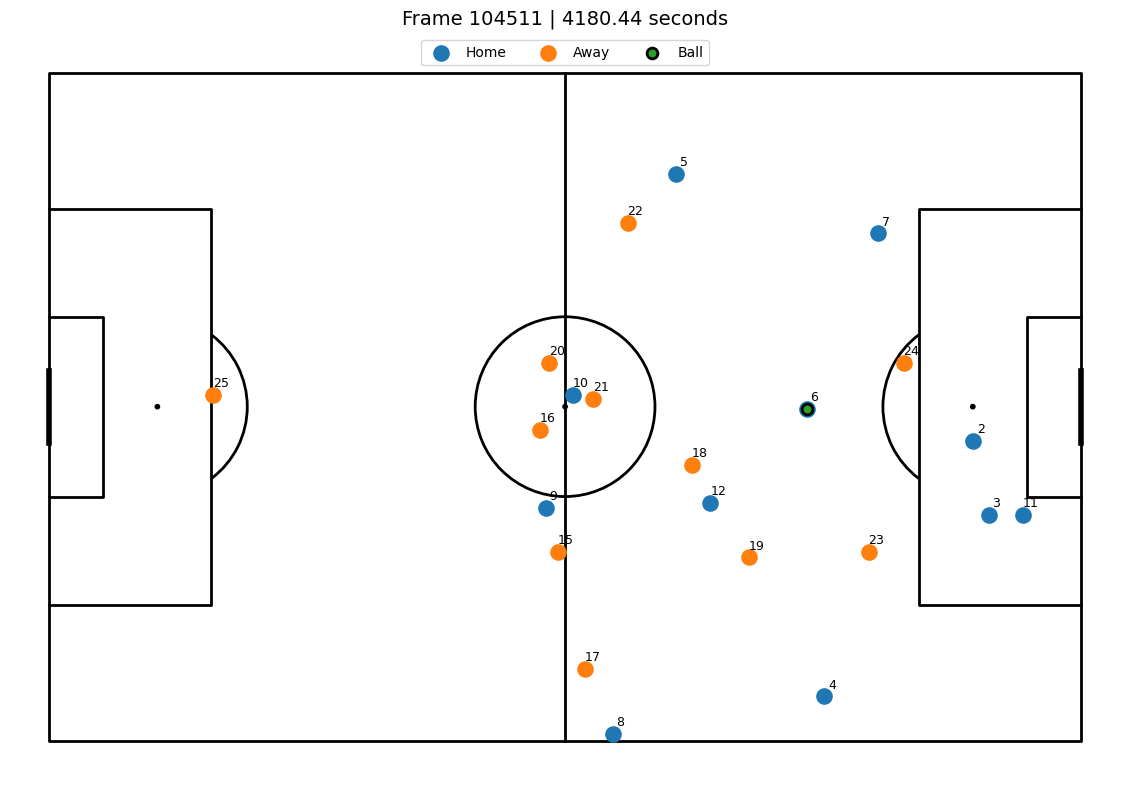

In [40]:
# Player x-coordinate columns (exclude the ball)
home_x_cols = [
    c for c in home.columns
    if c.startswith("Player") and c.endswith("_x")
]

away_x_cols = [
    c for c in away.columns
    if c.startswith("Player") and c.endswith("_x")
]

# Corresponding y-coordinate columns
home_y_cols = [c.replace("_x", "_y") for c in home_x_cols]
away_y_cols = [c.replace("_x", "_y") for c in away_x_cols]

home_active = active_players(home_frame, home_x_cols)
away_active = active_players(away_frame, away_x_cols)

# Create pitch
pitch = Pitch(
    pitch_type="custom",
    pitch_length=105,
    pitch_width=68,
    pitch_color="white",
    line_color="black"
)

fig, ax = pitch.draw(figsize=(12, 8))

# Home players
ax.scatter(
    home_frame[home_x_cols],
    home_frame[home_y_cols],
    s=120,
    label="Home",
    zorder=3
)

# Away players
ax.scatter(
    away_frame[away_x_cols],
    away_frame[away_y_cols],
    s=120,
    label="Away",
    zorder=3
)

# Ball
ax.scatter(
    home_frame["Ball_x"],
    home_frame["Ball_y"],
    s=60,
    marker="o",
    edgecolor="black",
    linewidth=2,
    label="Ball",
    zorder=4
)

ax.legend(loc="upper center", ncol=3)

ax.set_title(
    f"Frame {int(home_frame['Frame'])} | "
    f"{home_frame['Time [s]']:.2f} seconds",
    fontsize=14
)

for player, x, y in home_active:
    ax.text(x + 0.8, y + 0.8, player.replace("Player", ""),
            fontsize=9, ha="center")

for player, x, y in away_active:
    ax.text(x + 0.8, y + 0.8, player.replace("Player", ""),
            fontsize=9, ha="center")

plt.show()

Synchronize events with tracking

In [41]:
print(events["Team"].unique())
print(events["Type"].value_counts())

<ArrowStringArray>
['Away', 'Home']
Length: 2, dtype: str
Type
PASS              799
RECOVERY          278
BALL LOST         257
CHALLENGE         233
SET PIECE          77
BALL OUT           51
SHOT               24
FAULT RECEIVED     22
CARD                4
Name: count, dtype: int64


Convert the event coordinates to the same metre-based system as the tracking data.

In [42]:
def convert_event_coordinates(df):
    df = df.copy()

    for col in ["Start X", "End X"]:
        df[col] = df[col] * 105

    for col in ["Start Y", "End Y"]:
        df[col] = (1 - df[col]) * 68

    return df

events_m = convert_event_coordinates(events)

Look at the first pass.

In [43]:
passes = events_m[events_m["Type"] == "PASS"].copy()

first_pass = passes.iloc[0]

first_pass[
    ["Team", "From", "To", "Start Frame", "Start Time [s]",
     "Start X", "Start Y", "End X", "End Y"]
]

Team                  Away
From              Player19
To                Player21
Start Frame              1
Start Time [s]        0.04
Start X              47.25
Start Y              41.48
End X                57.75
End Y                38.76
Name: 1, dtype: object

Based on Start Frame get the corresponding tracking data.

In [44]:
pass_frame = int(first_pass["Start Frame"])

home_pass_frame = home.loc[home["Frame"] == pass_frame].iloc[0]
away_pass_frame = away.loc[away["Frame"] == pass_frame].iloc[0]

print("Pass frame:", pass_frame)
print("Team:", first_pass["Team"])
print("Passer:", first_pass["From"])
print("Receiver:", first_pass["To"])

Pass frame: 1
Team: Away
Passer: Player19
Receiver: Player21


In [45]:
print(
    "Event ball location:",
    first_pass["Start X"],
    first_pass["Start Y"]
)

print(
    "Tracking ball location:",
    home_pass_frame["Ball_x"],
    home_pass_frame["Ball_y"]
)

Event ball location: 47.25 41.48
Tracking ball location: 47.7456 41.67788


They are reasonable close so this is fine.